In [1]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
IMG_SIZE = (224,224)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

feature_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

base_model.trainable = False

In [3]:
dataset_path = "C:/Users\Sujal Pal\OneDrive\Desktop/New Deep Learning\CNN/archive (1)"
classes = ["Anemic", "Non-anemic"]

X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        try:
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)/255.0
            img_array = np.expand_dims(img_array, axis=0)

            features = feature_model.predict(img_array, verbose=0)

            X.append(features.flatten())
            y.append(label)

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (4260, 2048)


In [4]:
df = pd.DataFrame(X)
df['label'] = y
df.to_csv("resnet50_features.csv", index=False)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
print(X_train.shape , X_test.shape , y_train.shape , y_test.shape)

(3408, 2048) (852, 2048) (3408,) (852,)


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [9]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)

y_pred_lr = grid_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

Best LR Params: {'C': 10, 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.67      0.87      0.76       512
           1       0.65      0.35      0.46       340

    accuracy                           0.66       852
   macro avg       0.66      0.61      0.61       852
weighted avg       0.66      0.66      0.64       852



In [10]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

y_pred_rf = grid_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       512
           1       0.94      0.83      0.88       340

    accuracy                           0.91       852
   macro avg       0.92      0.90      0.90       852
weighted avg       0.91      0.91      0.91       852



In [11]:
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)

y_pred_svm = grid_svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.65      0.92      0.76       512
           1       0.67      0.25      0.37       340

    accuracy                           0.65       852
   macro avg       0.66      0.58      0.56       852
weighted avg       0.66      0.65      0.60       852



In [12]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

for k, v in results.items():
    print(f"{k}: {v:.4f}")

Logistic Regression: 0.6643
Random Forest: 0.9096
SVM: 0.6514


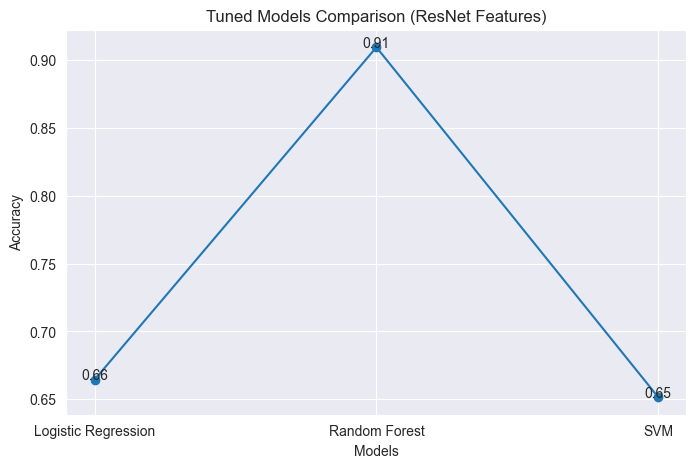

In [13]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))
plt.plot(models, accuracies, marker='o')

plt.title("Tuned Models Comparison (ResNet Features)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(True)

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()